# Principal Component Analysis (PCA)

The objective of this notebook is to reduce the dimensionality of the engineered feature space while preserving as much information as possible.

The feature engineering stage produced three variables describing different aspects of Bitcoin market behavior:

- Returns
- Volatility
- Momentum

Although these features provide valuable information, some of their variability may overlap. Principal Component Analysis (PCA) transforms the original features into a new set of orthogonal components that capture the dominant patterns present in the data.

These principal components will subsequently be used as inputs for clustering algorithms in order to identify distinct market regimes.

In [1]:
# Load librarys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
%matplotlib inline

# Ruta absoluta a la raíz del proyecto
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [ ]:
# Load feature dataset
asset_name = [asset.lower().replace("-", "_") for asset in ASSETS]

feature_path = (f"{PROCESSED_DATA_PATH}/{asset_name}_features.csv")

df = pd.read_csv(feature_path)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()

,Returns,Volatility,Momentum
Date,,,
2018-01-31,0.011359,0.064866,-0.086472
2018-02-01,-0.102783,0.064014,-0.200817
2018-02-02,-0.037052,0.063907,-0.239214
2018-02-03,0.038973,0.064239,-0.288723
2018-02-04,-0.097865,0.060821,-0.286471


------

### Dataset Verification

The final feature dataset contains 3,051 observations and three engineered variables: Returns, Volatility, and Momentum.

All features are stored as numerical variables (`float64`), making them directly suitable for mathematical transformations and machine learning algorithms. Furthermore, no missing values remain after the feature engineering stage, confirming that the dataset is fully prepared for dimensionality reduction.

The resulting feature matrix provides a compact representation of Bitcoin market behavior and serves as the input for Principal Component Analysis (PCA).

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3051
Columns: 3
<class 'pandas.DataFrame'>
DatetimeIndex: 3051 entries, 2018-01-31 to 2026-06-08
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Returns     3051 non-null   float64
 1   Volatility  3051 non-null   float64
 2   Momentum    3051 non-null   float64
dtypes: float64(3)
memory usage: 95.3 KB


------

## Feature Scaling

Principal Component Analysis is sensitive to the scale of the input variables. Features with larger numerical ranges can dominate the resulting principal components, even if they are not inherently more informative.

To ensure that Returns, Volatility, and Momentum contribute equally to the analysis, all features are standardized using StandardScaler. This transformation centers each feature around zero and scales it to unit variance.

In [4]:
# Use standar scaler to standarize all the variables
from sklearn.preprocessing import StandardScaler

# Define the features
features = [
    "Returns",
    "Volatility",
    "Momentum"
]

# Apply the StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[features])

In [5]:
# Convert back to DataFrame
scaled_df = pd.DataFrame(
    scaled_features, 
    columns = features, 
    index = df.index
)

scaled_df.head()

,Returns,Volatility,Momentum
Date,,,
2018-01-31,0.308262,2.666907,-0.789169
2018-02-01,-3.139880,2.600338,-1.664864
2018-02-02,-1.154207,2.592011,-1.958916
2018-02-03,1.142445,2.617944,-2.338070
2018-02-04,-2.991292,2.350934,-2.320826


In [6]:
# Validation of scaling
scaled_df.describe()

,Returns,Volatility,Momentum
count,3.051000e+03,3051.000000,3051.000000
mean,5.822212e-18,0.000000,0.000000
std,1.000164e+00,1.000164,1.000164
min,-1.126346e+01,-1.705842,-3.455620
25%,-4.408701e-01,-0.680713,-0.551818
50%,-1.596328e-02,-0.203028,-0.072927
75%,4.197834e-01,0.461372,0.463196
max,5.628243e+00,4.734112,4.917675


### Interpretation

The standardized feature matrix confirms that all variables have been successfully transformed to a common scale. Following standardization, each feature exhibits a mean approximately equal to zero and a standard deviation approximately equal to one.

This transformation ensures that Returns, Volatility, and Momentum contribute equally to the PCA computation, preventing features with larger numerical ranges from dominating the analysis.

The presence of extreme standardized values indicates that unusually large market movements and trend events remain represented within the dataset. However, these observations are now expressed relative to each feature's own variability, allowing meaningful comparison across variables.

The standardized dataset is therefore suitable for dimensionality reduction using Principal Component Analysis.

--------

## Principal Component Analysis

After standardizing the feature matrix, Principal Component Analysis (PCA) is applied to identify the dominant patterns present in the data.

PCA transforms the original features into a new set of orthogonal variables called principal components. Each component captures a portion of the total variance present in the dataset, with the first component explaining the largest amount of variability.

The objective is to determine how many components are required to preserve most of the information contained in the engineered feature space.

In [7]:
# Import PCA from scikit-learn
from sklearn.decomposition import PCA 

# Create the pca object
pca = PCA()

# Fit PCA to the scaled features
pca.fit(scaled_features)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [8]:
# Create the components we want
explained_variance = pd.DataFrame({
    "Principal Component": [ f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))], # It creates a list of labels like ['PC1', 'PC2', 'PC3', ...]
    "Explained Variance Ratio": pca.explained_variance_ratio_, # It pulls the raw percentage of variance (information) that each individual component is responsible for.
    "Cumulative Variance": np.cumsum( pca.explained_variance_ratio_) # It keeps a running tally (a total sum) of the variance as you add more components.
})

explained_variance

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.424451,0.424451
1,PC2,0.334210,0.758660
2,PC3,0.241340,1.000000


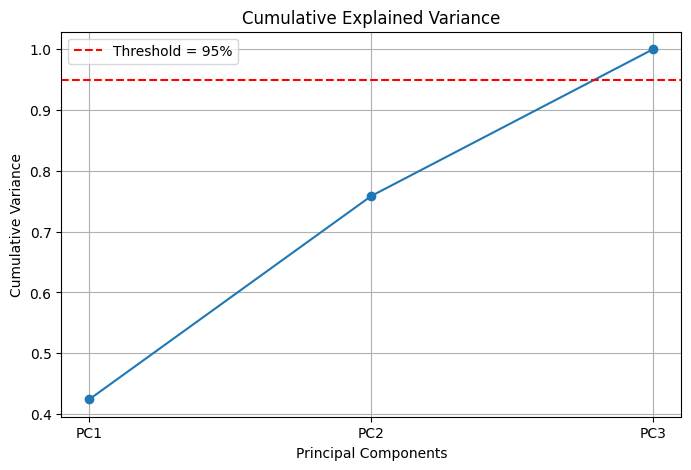

In [9]:
# Visualize cumulative explained variance

plt.figure(figsize=(8,5))

plt.plot(
    explained_variance["Principal Component"],
    explained_variance["Cumulative Variance"],
    marker="o"
)

plt.axhline(
    y=PCA_VARIANCE_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Threshold = {PCA_VARIANCE_THRESHOLD:.0%}"
)

plt.ylabel("Cumulative Variance")
plt.xlabel("Principal Components")

plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

The PCA results indicate that variance is distributed across all three principal components. The first component explains 42.45% of the total variance, while the first two components together explain 75.87%. To preserve at least 95% of the information contained in the feature space, all three principal components must be retained.

This suggests that Returns, Volatility, and Momentum capture complementary aspects of market behavior rather than redundant information. Consequently, dimensionality reduction provides limited compression benefits for this feature set, although PCA remains useful for understanding variance structure and preparing the data for clustering.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

loadings

,PC1,PC2,PC3
Returns,0.704030,0.115233,-0.700759
Volatility,-0.052771,0.992508,0.110192
Momentum,0.708207,-0.040599,0.704837


### PCA Loadings Interpretation

The first principal component is primarily influenced by Returns and Momentum, suggesting that it captures the overall direction and strength of market trends. This component explains 42.45% of the total variance.

The second principal component is almost entirely driven by Volatility, indicating that it represents market risk and turbulence. This component explains 33.42% of the variance and provides a distinct view of changing market conditions independent of price direction.

The third principal component contrasts Returns and Momentum, suggesting that it captures periods in which short-term price movements diverge from longer-term trends. Such behavior may occur during market transitions, reversals, or periods of uncertainty.

Together, the PCA decomposition reveals that Bitcoin market behavior can be broadly described through three latent dimensions: trend strength, volatility regime, and trend-transition dynamics.

------

## PCA Projection Visualization

After transforming the original feature space into principal components, it is useful to visualize the observations in the reduced PCA space.

The scatter plot below displays each observation using the first two principal components (PC1 and PC2), which together explain approximately 75.87% of the total variance in the dataset.

This visualization provides an initial assessment of whether natural groupings or market structures exist within the transformed feature space before applying clustering algorithms for market regime detection.

### Component Selection

Rather than specifying a fixed number of principal components, the PCA model uses the variance threshold defined in the project configuration. Components are retained until the cumulative explained variance reaches at least 95% of the total variance.

This approach ensures that the dimensionality reduction process adapts automatically if additional engineered features are introduced in future versions of the project.

In [11]:
# Create a PCA object with the number of components we want to keep using the TRESHOLD config
pca = PCA(n_components=PCA_VARIANCE_THRESHOLD)

pca_data = pca.fit_transform(scaled_df)

# add components names 
component_names = [ f"PC{i+1}" for i in range(pca.n_components_)]

pca_df = pd.DataFrame(
    pca_data,
    columns= component_names,
    index=scaled_df.index
)

# Number of  components selected
print(
    f"Components selected: "
    f"{pca.n_components_}"
)

pca_df.head()

Components selected: 3


,PC1,PC2,PC3
Date,,,
2018-01-31,-0.482604,2.714489,-0.478382
2018-02-01,-3.526860,2.286630,1.313377
2018-02-02,-2.336696,2.519119,-0.286278
2018-02-03,-0.989673,2.824902,-2.160061
2018-02-04,-3.873645,2.082848,0.719425


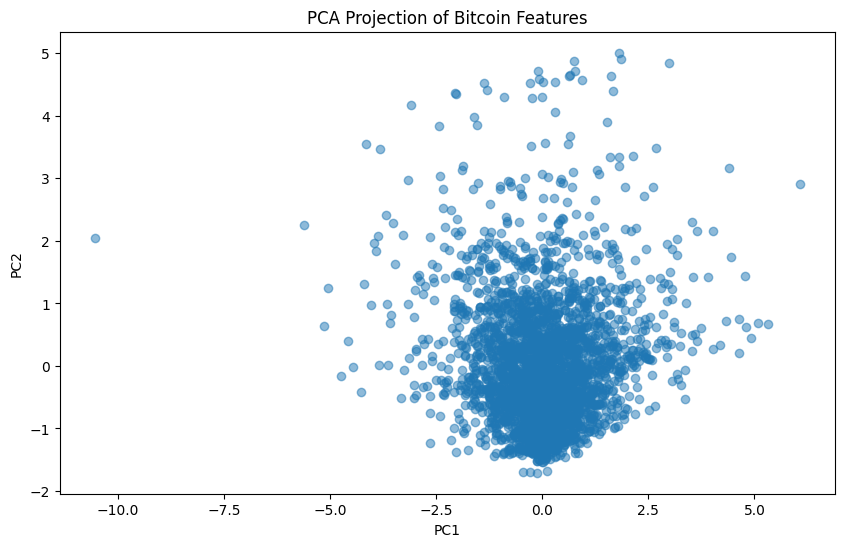

In [12]:
# Visualize the PCA projection
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Bitcoin Features")

plt.show()

### Interpretation

The PCA projection reveals that the majority of observations are concentrated around the center of the transformed feature space, indicating that most trading days exhibit relatively typical market behavior.

Several observations appear far from the central cluster, suggesting the presence of extreme market conditions characterized by unusual combinations of trend strength and volatility. These observations likely correspond to significant market events, rapid price movements, or periods of elevated uncertainty.

Although the visualization does not display clearly separated clusters, a meaningful structure is still present within the data. This behavior is common in financial markets, where regime boundaries tend to be gradual rather than sharply defined.

The PCA projection therefore suggests that clustering algorithms may be capable of identifying distinct market regimes based on differences in trend and volatility characteristics, even if those regimes are not visually separable in a two-dimensional representation.

-----

### Export Results
The final step of the PCA stage is to persist all artifacts required for downstream analysis. This includes the transformed PCA dataset used for clustering, as well as the fitted preprocessing objects. Saving these artifacts guarantees reproducibility and allows future data to be transformed using the exact same scaling and PCA configuration.

In [13]:
# Imports needed
import joblib

In [14]:
# Paths for the exports
pca_output_path = ( 
    f"{PROCESSED_DATA_PATH}/" 
    f"{asset_name}_pca.csv" 
)

scaler_output_path = (
    f"{MODELS_PATH}/"
    f"{asset_name}_scaler.pkl"
)

pca_model_output_path = (
    f"{MODELS_PATH}/"
    f"{asset_name}_pca.pkl"
)

In [15]:
# Save in Processed 
pca_df.to_csv(pca_output_path)

# Save in models
joblib.dump(
    scaler, 
    scaler_output_path
)

joblib.dump(
    pca,
    pca_model_output_path
)

# Verify where it's saved
print( 
    f"PCA dataset saved to: " 
    f"{pca_output_path}" 
)

print(
    f"Scaler saved to: "
    f"{scaler_output_path}"
)

print(
    f"PCA model saved to: "
    f"{pca_model_output_path}"
)

PCA dataset saved to: ../data/processed/btc_usd_pca.csv
Scaler saved to: ../outputs/models/btc_usd_scaler.pkl
PCA model saved to: ../outputs/models/btc_usd_pca.pkl


In [17]:
# Export summary
print("=" * 50)
print("PCA EXPORT SUMMARY")
print("=" * 50)

print(f"Dataset: {asset_name}")
print(f"Principal Components: {pca.n_components_}")

print(
    f"Cumulative Variance Explained: "
    f"{explained_variance['Cumulative Variance'].iloc[-1]:.2%}"
)

print(f"PCA Dataset: {pca_output_path}")
print(f"Scaler: {scaler_output_path}")
print(f"PCA Model: {pca_model_output_path}")

PCA EXPORT SUMMARY
Dataset: btc_usd
Principal Components: 3
Cumulative Variance Explained: 100.00%
PCA Dataset: ../data/processed/btc_usd_pca.csv
Scaler: ../outputs/models/btc_usd_scaler.pkl
PCA Model: ../outputs/models/btc_usd_pca.pkl


------ 

## PCA Conclusion

Principal Component Analysis was applied to the engineered feature set composed of Returns, Volatility, and Momentum in order to understand the underlying structure of Bitcoin market behavior.

The results showed that variance is distributed across all three principal components, indicating that each engineered feature contributes unique information to the dataset. The first principal component primarily captures market trend strength, the second represents volatility dynamics, and the third reflects potential trend-transition behavior.

The PCA loadings reveal that market behavior can be described through three latent dimensions: trend direction, market risk, and trend reversals. This finding suggests that the selected features successfully capture complementary aspects of cryptocurrency market activity.

Although the PCA projection does not exhibit clearly separated clusters, the transformed feature space displays meaningful structure and several extreme observations associated with unusual market conditions. Such behavior is common in financial datasets, where regime boundaries are often gradual rather than sharply defined.

Overall, PCA provides valuable insight into the structure of the feature space and confirms that the engineered variables contain sufficient information to support the next stage of the project: clustering-based market regime detection.